# E-commerce Purchase Prediction Using Logistic Regression

## 1. Import Libraries

In [7]:
# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Notebook / plotting settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


### 2. Load Dataset

In [8]:
df = pd.read_csv("/content/dataset_04_ecommerce_purchase_intent.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset loaded: 1000 rows, 7 columns


**First 5 rows:**

In [9]:
df.head()

,pages_viewed,session_minutes,products_viewed,cart_additions,discount_seen,previous_orders,target
0,27,24.79,3,5,3,5,0
1,54,13.29,2,5,2,5,1
2,45,2.00,5,2,2,1,1
3,50,50.66,5,6,3,3,0
4,34,43.77,2,3,3,1,1


**Last 5 rows:**

In [10]:
df.tail()

,pages_viewed,session_minutes,products_viewed,cart_additions,discount_seen,previous_orders,target
995,39,11.02,1,1,1,4,1
996,61,61.20,2,2,4,3,1
997,23,2.00,3,2,1,2,1
998,21,44.76,4,2,5,1,0
999,38,47.78,4,7,2,8,0


**Shape (rows, columns):**

In [11]:
df.shape

(1000, 7)

**Column names:**

In [12]:
df.columns.tolist()

['pages_viewed',
 'session_minutes',
 'products_viewed',
 'cart_additions',
 'discount_seen',
 'previous_orders',
 'target']

**Dataset info (dtypes, non-null counts):**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pages_viewed     1000 non-null   int64  
 1   session_minutes  1000 non-null   float64
 2   products_viewed  1000 non-null   int64  
 3   cart_additions   1000 non-null   int64  
 4   discount_seen    1000 non-null   int64  
 5   previous_orders  1000 non-null   int64  
 6   target           1000 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 54.8 KB


**Data types:**

In [14]:
df.dtypes

,0
pages_viewed,int64
session_minutes,float64
products_viewed,int64
cart_additions,int64
discount_seen,int64
previous_orders,int64
target,int64


## 3. Data Understanding

### Feature descriptions

| Column | Type | Meaning |
|---|---|---|
| `pages_viewed` | Numerical (int) | Number of distinct pages the visitor opened during the session |
| `session_minutes` | Numerical (float) | Total duration of the browsing session, in minutes |
| `products_viewed` | Numerical (int) | Number of distinct product pages the visitor viewed |
| `cart_additions` | Numerical (int) | Number of times an item was added to the shopping cart |
| `discount_seen` | Numerical (int) | Number of discount/promotion banners or offers shown to the visitor during the session |
| `previous_orders` | Numerical (int) | Number of orders this customer has completed in the past (returning-customer history) |
| `target` | Categorical (binary, int) | **Target variable.** `1` = the session ended in a purchase, `0` = it did not |

All six input features are numerical counts or durations. There are no free-text or high-cardinality categorical columns in this dataset, so no encoding of categorical variables is required.

**Numerical features:** `pages_viewed`, `session_minutes`, `products_viewed`, `cart_additions`, `discount_seen`, `previous_orders`
**Target variable:** `target` (binary: 0 = No Purchase, 1 = Purchase)


**Missing values per column:**

In [15]:
df.isnull().sum()

,0
pages_viewed,0
session_minutes,0
products_viewed,0
cart_additions,0
discount_seen,0
previous_orders,0
target,0


**Duplicate rows:**

In [16]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


**Unique values per column:**

In [17]:
df.nunique()

,0
pages_viewed,48
session_minutes,889
products_viewed,10
cart_additions,11
discount_seen,10
previous_orders,10
target,2


**Checking for invalid values.**
Since every column is a count or a duration, values below zero would be invalid, and (for `discount_seen`) an implausibly extreme count would also be worth flagging. We check the minimum and maximum of each numerical column below.


In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pages_viewed,1000.0,40.79200,13.904030,18.0,29.00,40.000,53.0000,65.00
session_minutes,1000.0,36.40529,18.669218,2.0,23.03,36.705,49.6075,99.35
products_viewed,1000.0,2.92200,1.735202,0.0,2.00,3.000,4.0000,10.00
cart_additions,1000.0,2.94100,1.715360,0.0,2.00,3.000,4.0000,10.00
discount_seen,1000.0,2.91300,1.684716,0.0,2.00,3.000,4.0000,9.00
previous_orders,1000.0,3.02400,1.733906,0.0,2.00,3.000,4.0000,9.00
target,1000.0,0.50000,0.500250,0.0,0.00,0.500,1.0000,1.00


**Class distribution of the target variable:**

In [19]:
target_counts = df["target"].value_counts()
target_pct = df["target"].value_counts(normalize=True) * 100

print("Counts:")
print(target_counts)
print("\nPercentages:")
print(target_pct.round(2))


Counts:
target
0    500
1    500
Name: count, dtype: int64

Percentages:
target
0    50.0
1    50.0
Name: proportion, dtype: float64


/tmp/ipykernel_14496/3587433821.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="target", data=df, palette=["#e74c3c", "#2ecc71"])
/tmp/ipykernel_14496/3587433821.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Purchase (0)", "Purchase (1)"])


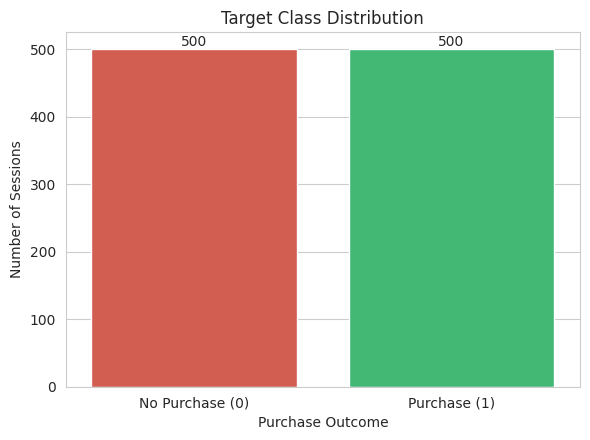

In [20]:
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(x="target", data=df, palette=["#e74c3c", "#2ecc71"])
ax.set_xticklabels(["No Purchase (0)", "Purchase (1)"])
plt.title("Target Class Distribution")
plt.xlabel("Purchase Outcome")
plt.ylabel("Number of Sessions")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig("/content/figures/01_target_distribution.png", dpi=150)
plt.show()


> **Interpretation:** The dataset is balanced, with an equal (or near-equal) number of purchase and non-purchase sessions. A balanced target means accuracy is a meaningful metric here (unlike heavily imbalanced problems), although we still report precision, recall and F1 for a fuller picture.


## 4. Data Cleaning

Based on the checks above:

- **Missing values:** none were found — no imputation is required.
- **Duplicate rows:** none were found — no rows need to be dropped.
- **Data types:** all columns already have appropriate numeric types (`int64` / `float64`); no type conversion is required.
- **Invalid values:** all minimums are at or above zero and all maximums are within a plausible range for session-level counts and durations, so no rows are removed as invalid.

Because the dataset is already clean, no rows or columns are modified in this step. This is intentionally reported rather than assumed — the workflow always checks first and only cleans what actually needs cleaning.


In [21]:
# Re-confirm cleanliness programmatically (defensive check before modelling)
assert df.isnull().sum().sum() == 0, "Unexpected missing values found."
assert df.duplicated().sum() == 0, "Unexpected duplicate rows found."
assert (df.select_dtypes(include=[np.number]) >= 0).all().all(), "Unexpected negative values found."
print("Data cleaning checks passed: no missing values, no duplicates, no negative values.")

df_clean = df.copy()  # kept as a separate variable for clarity going forward


Data cleaning checks passed: no missing values, no duplicates, no negative values.


## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribution of numerical features

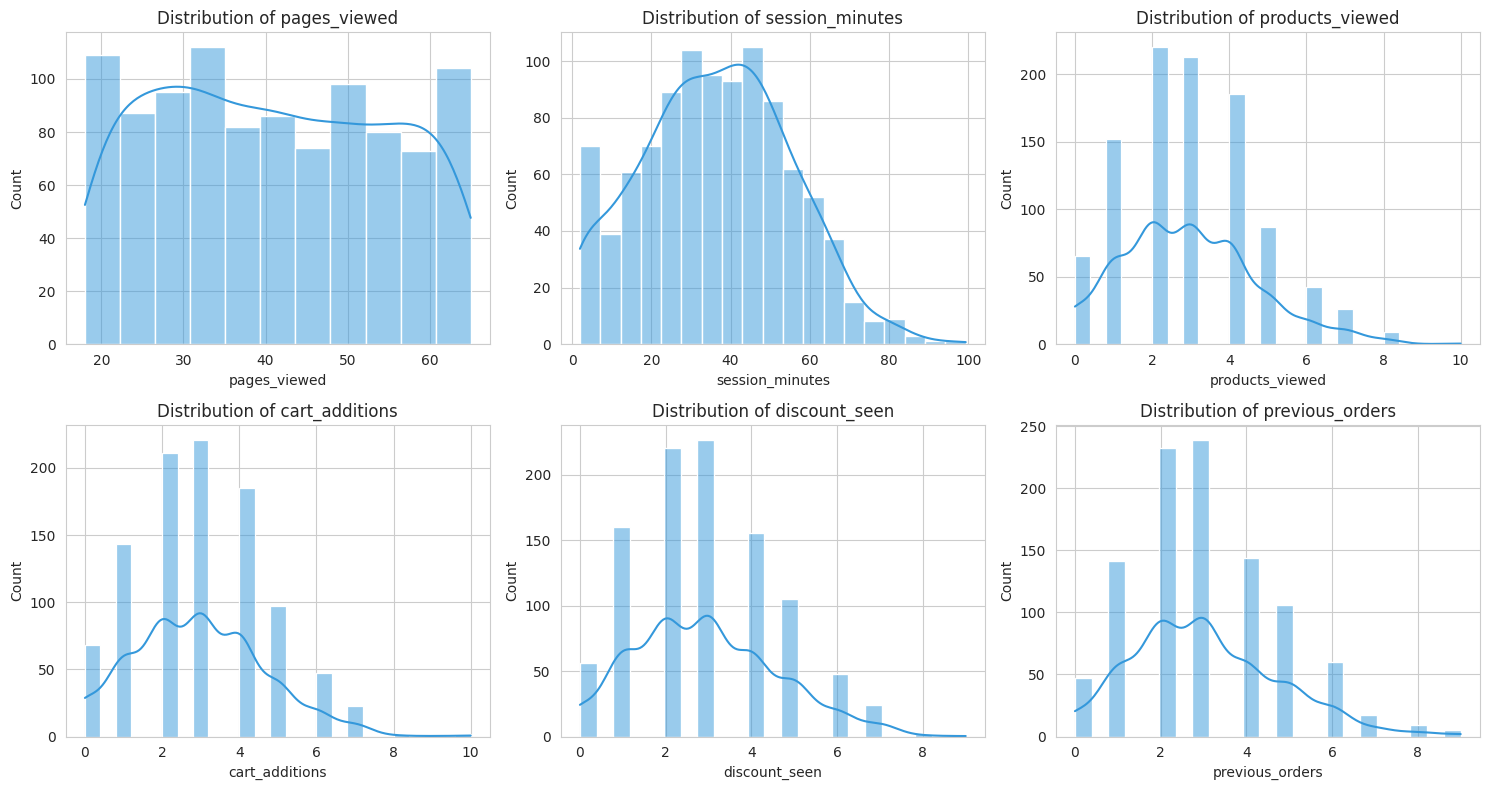

In [22]:
numeric_cols = ["pages_viewed", "session_minutes", "products_viewed",
                 "cart_additions", "discount_seen", "previous_orders"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color="#3498db")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("/content/figures/02_feature_distributions.png", dpi=150)
plt.show()


> **Interpretation:** `pages_viewed` and `session_minutes` are fairly spread out across their range, reflecting the mix of short and long browsing sessions. `products_viewed`, `cart_additions`, `discount_seen` and `previous_orders` are lower-count variables concentrated near single digits, which is expected for per-session interaction counts.


### 5.2 Boxplots for numerical features (outlier check)

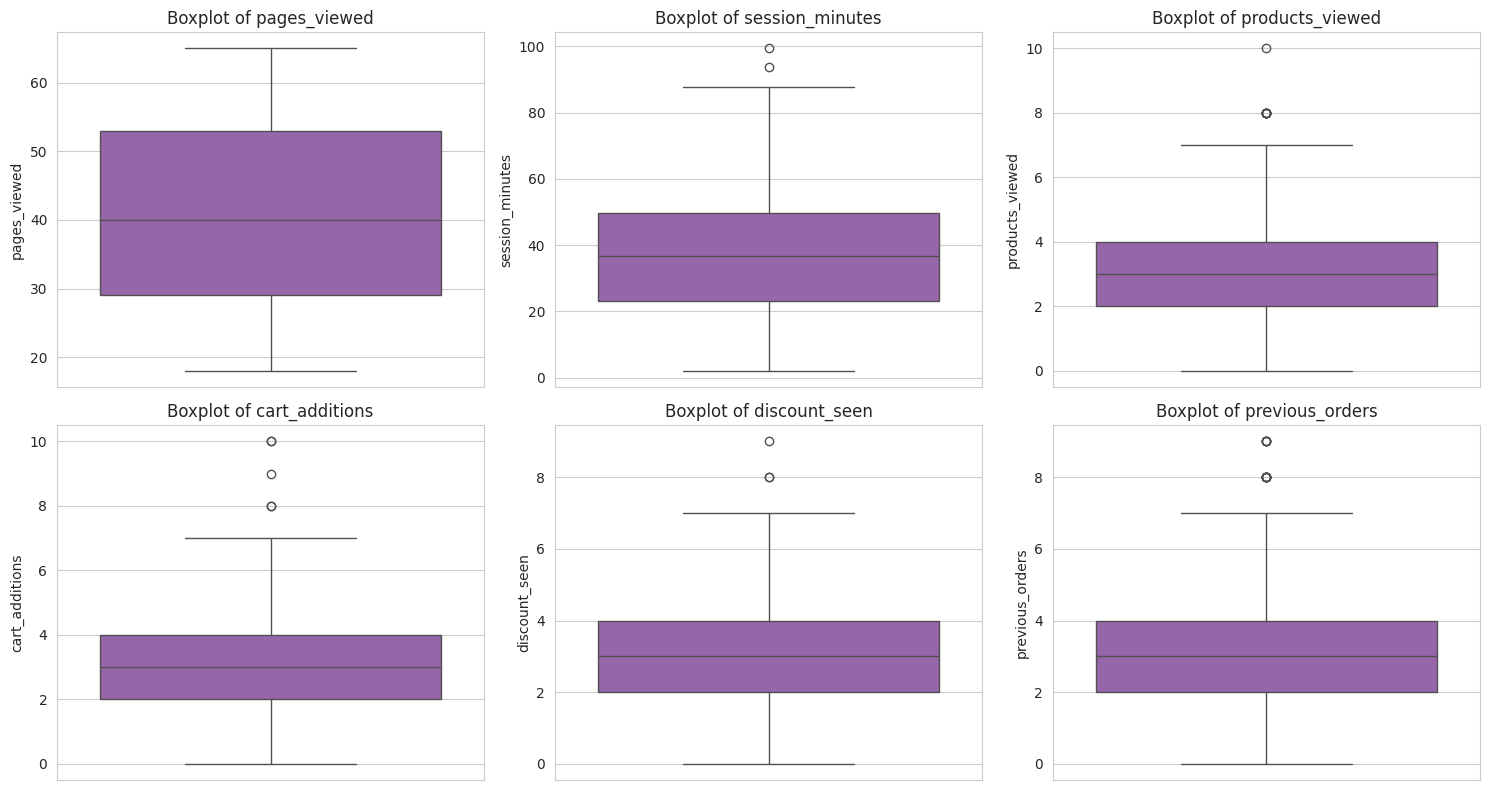

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color="#9b59b6")
    axes[i].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.savefig("/content/figures/03_feature_boxplots.png", dpi=150)
plt.show()


> **Interpretation:** None of the six features show extreme outliers that would need capping or removal — the boxplots show reasonably contained spreads consistent with the histograms above.


### 5.3 Purchase vs. session duration

/tmp/ipykernel_14496/3251053447.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="session_minutes", data=df_clean, palette=["#e74c3c", "#2ecc71"])


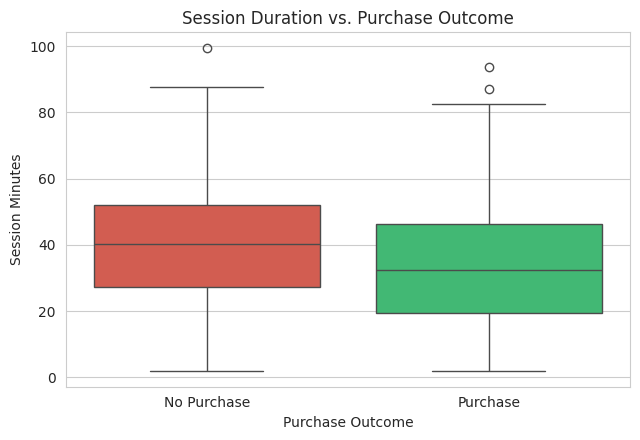

In [24]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(x="target", y="session_minutes", data=df_clean, palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["No Purchase", "Purchase"])
plt.title("Session Duration vs. Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Session Minutes")
plt.tight_layout()
plt.savefig("/content/figures/04_session_minutes_vs_target.png", dpi=150)
plt.show()


### 5.4 Purchase vs. pages viewed

/tmp/ipykernel_14496/1521425519.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="pages_viewed", data=df_clean, palette=["#e74c3c", "#2ecc71"])


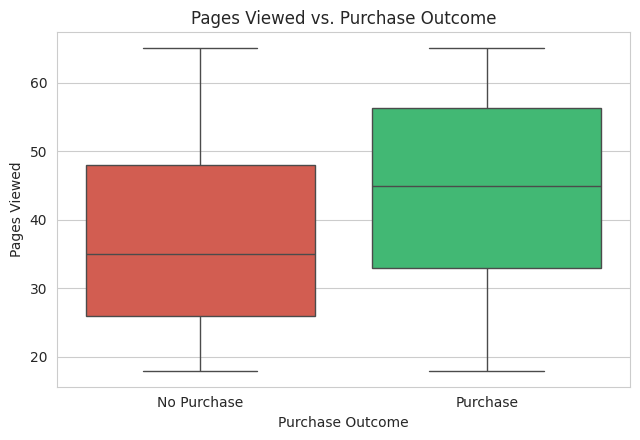

In [25]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(x="target", y="pages_viewed", data=df_clean, palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["No Purchase", "Purchase"])
plt.title("Pages Viewed vs. Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Pages Viewed")
plt.tight_layout()
plt.savefig("/content/figures/05_pages_viewed_vs_target.png", dpi=150)
plt.show()


### 5.5 Purchase vs. products viewed

/tmp/ipykernel_14496/1662638469.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="products_viewed", data=df_clean, palette=["#e74c3c", "#2ecc71"])


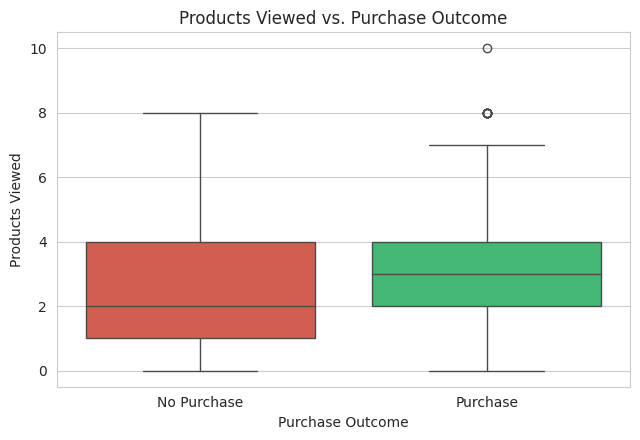

In [26]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(x="target", y="products_viewed", data=df_clean, palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["No Purchase", "Purchase"])
plt.title("Products Viewed vs. Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Products Viewed")
plt.tight_layout()
plt.savefig("/content/figures/06_products_viewed_vs_target.png", dpi=150)
plt.show()


### 5.6 Purchase vs. cart additions

/tmp/ipykernel_14496/820447511.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="cart_additions", data=df_clean, palette=["#e74c3c", "#2ecc71"])


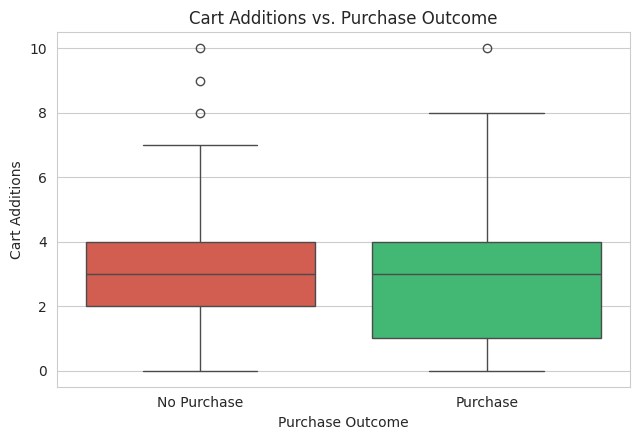

In [27]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(x="target", y="cart_additions", data=df_clean, palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["No Purchase", "Purchase"])
plt.title("Cart Additions vs. Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Cart Additions")
plt.tight_layout()
plt.savefig("/content/figures/07_cart_additions_vs_target.png", dpi=150)
plt.show()


### 5.7 Purchase vs. previous orders

/tmp/ipykernel_14496/3342113805.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="previous_orders", data=df_clean, palette=["#e74c3c", "#2ecc71"])


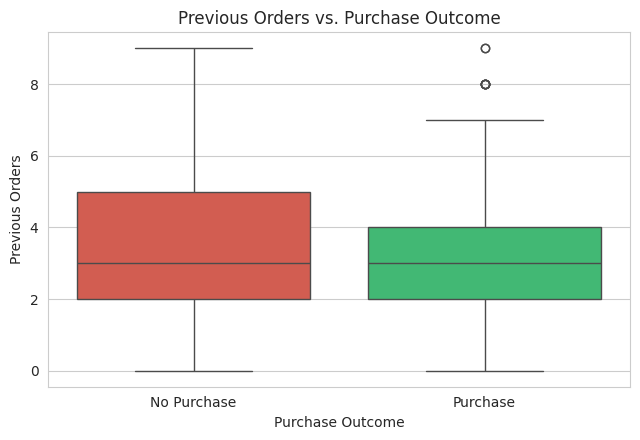

In [28]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(x="target", y="previous_orders", data=df_clean, palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["No Purchase", "Purchase"])
plt.title("Previous Orders vs. Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Previous Orders")
plt.tight_layout()
plt.savefig("/content/figures/08_previous_orders_vs_target.png", dpi=150)
plt.show()


### 5.8 Purchase vs. discount seen

/tmp/ipykernel_14496/2063941825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y="discount_seen", data=df_clean, palette=["#e74c3c", "#2ecc71"])


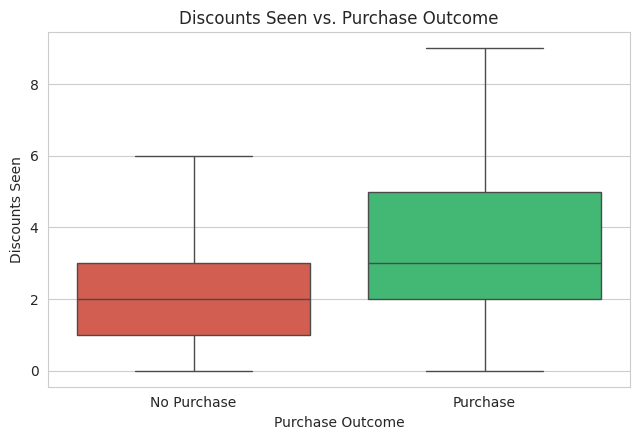

In [29]:
plt.figure(figsize=(6.5, 4.5))
sns.boxplot(x="target", y="discount_seen", data=df_clean, palette=["#e74c3c", "#2ecc71"])
plt.xticks([0, 1], ["No Purchase", "Purchase"])
plt.title("Discounts Seen vs. Purchase Outcome")
plt.xlabel("Purchase Outcome")
plt.ylabel("Discounts Seen")
plt.tight_layout()
plt.savefig("/content/figures/09_discount_seen_vs_target.png", dpi=150)
plt.show()


> **Interpretation of sections 6.3–6.8:** Sessions that end in a purchase tend to show **more** `pages_viewed`, `products_viewed` and `discount_seen`, but **shorter** `session_minutes` and **fewer** `cart_additions` and `previous_orders` compared to non-purchase sessions. Some of these directions are intuitive (browsing more products, seeing more discounts) while others are less obvious (fewer cart additions and fewer previous orders among buyers) — this is exactly why we let the model estimate the relationships from data rather than assuming them, and we revisit these patterns quantitatively in the coefficient analysis (Section 15).


### 5.9 Correlation heatmap

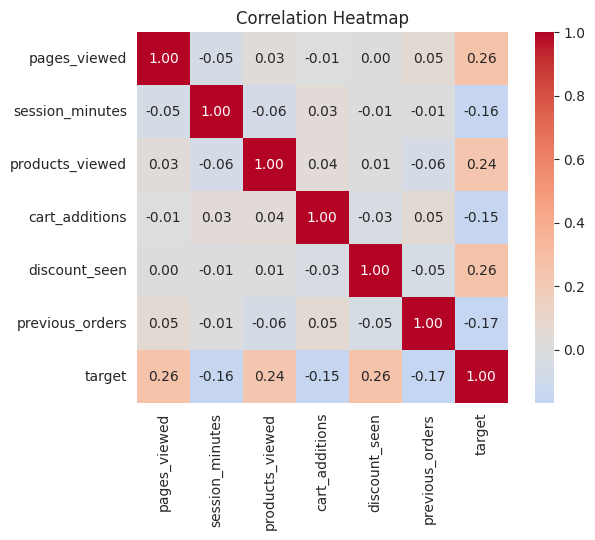

In [31]:
plt.figure(figsize=(7, 5.5))
corr = df_clean[numeric_cols + ["target"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("/content/figures/10_correlation_heatmap.png", dpi=150)
plt.show()


> **Interpretation:** No pair of input features is strongly correlated with another (all pairwise correlations are modest), so multicollinearity is not a concern for this Logistic Regression model. Each feature also shows a mild-to-moderate correlation with `target`, which is consistent with the boxplot findings above — no single feature dominates, so the model needs to combine several weak signals.


### 5.10 Pairwise relationship between behavioural features, coloured by purchase outcome

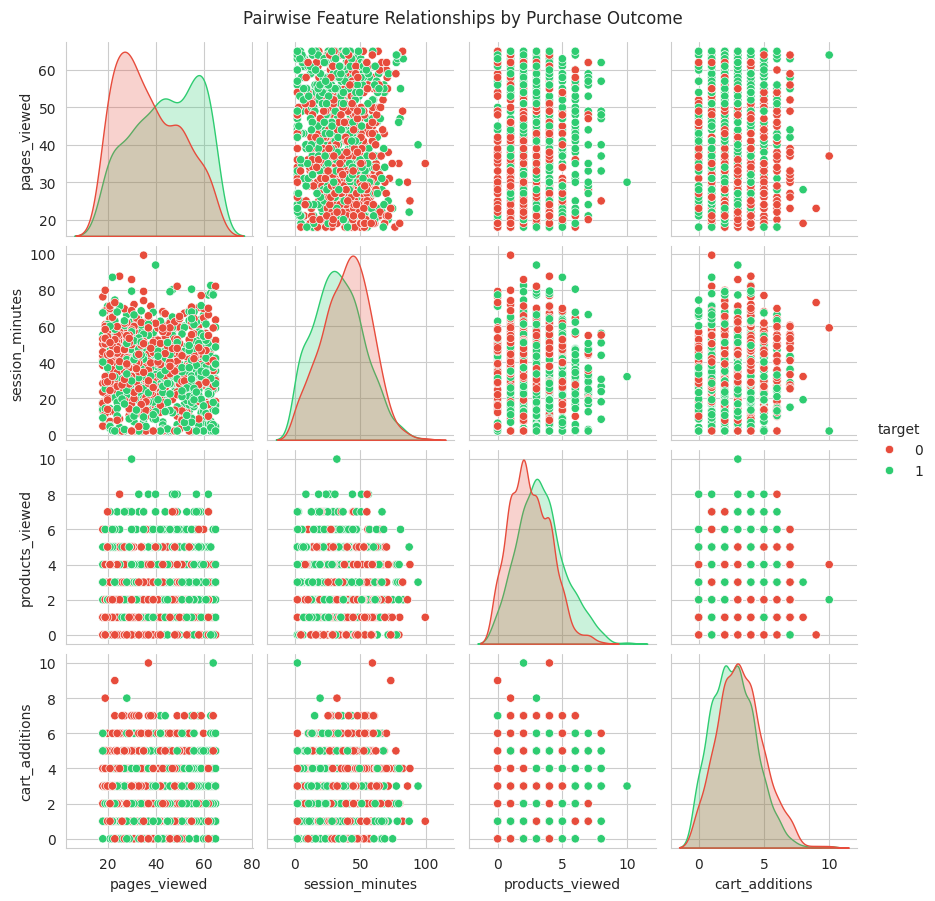

In [37]:
sns.pairplot(df_clean, vars=["pages_viewed", "session_minutes", "products_viewed", "cart_additions"],
             hue="target", palette=["#e74c3c", "#2ecc71"], diag_kind="kde", height=2.2)
plt.suptitle("Pairwise Feature Relationships by Purchase Outcome", y=1.02)
plt.savefig("/content/figures/11_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()


> **Interpretation:** No single pair of features cleanly separates purchasers from non-purchasers visually; the classes overlap substantially in two dimensions. This supports using a model like Logistic Regression that combines all features together rather than relying on any one feature in isolation.


## 6. Feature Selection

- **X (independent / input features):** `pages_viewed`, `session_minutes`, `products_viewed`, `cart_additions`, `discount_seen`, `previous_orders`
- **y (target / output):** `target`

All six behavioural features are used because:
1. Each showed a measurable (if modest) relationship with the target in the EDA above.
2. None of them are near-duplicates of each other (correlation heatmap), so each contributes distinct information.
3. All are available at prediction time (i.e., they describe the session *as it happens*, not something only known after the outcome), so using them does not leak the answer.


In [36]:
X = df_clean[numeric_cols]
y = df_clean["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1000, 6)
y shape: (1000,)


## 7. Train-Test Split

We use an 80/20 train-test split. `stratify=y` preserves the original class balance in both the training and test sets, and `random_state=42` makes the split reproducible.


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")
print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest set class balance:")
print(y_test.value_counts(normalize=True).round(3))


Training set: 800 rows
Test set: 200 rows

Training set class balance:
target
1    0.5
0    0.5
Name: proportion, dtype: float64

Test set class balance:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


## 8. Feature Scaling

Logistic Regression is fit using gradient-based optimisation, and it uses a single regularisation penalty applied uniformly across all coefficients. Because our features are on very different scales (e.g., `session_minutes` ranges up to ~100, while `cart_additions` ranges from 0–10), **feature scaling is appropriate** here — it helps the optimiser converge reliably and prevents large-scale features from being penalised more harshly than small-scale ones purely because of their units.

We use `StandardScaler` (zero mean, unit variance) inside a `Pipeline`, so that the scaler is *fit only on the training data* and then applied to the test data — this avoids data leakage from the test set into the training process.


In [39]:
# Scaling is handled inside the Pipeline below (Section 10), so no separate
# scaling step is performed here. This keeps fit/transform strictly
# confined to the training fold and prevents leakage.
print("Feature scaling will be applied via StandardScaler inside the modelling Pipeline (see Section 10).")


Feature scaling will be applied via StandardScaler inside the modelling Pipeline (see Section 10).


## 9. Train Logistic Regression Model

### What is Logistic Regression?
Logistic Regression models the **probability** that a binary outcome equals 1, as a function of the input features. It does this by first computing a linear combination of the features (like linear regression), and then passing that value through the **sigmoid function**:

$$P(y=1 \mid X) = \sigma(z) = \frac{1}{1 + e^{-z}}, \qquad z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$$

The sigmoid function squashes any real-valued input into the range (0, 1), which is exactly what is needed to represent a probability.

### Why is it suitable here?
Our target (`target`) only takes two values (0 or 1), which is precisely the setting Logistic Regression was designed for. It also produces an interpretable, probability-based output rather than an arbitrary score.

### What does the model learn?
The model learns one **coefficient (weight)** per feature. Each coefficient represents how much the *log-odds* of purchase change for a one-unit increase in that (scaled) feature, holding the others constant.

### What does the output probability mean?
For any session, the model outputs a number between 0 and 1 — the estimated probability that the session ends in a purchase. A threshold (0.5 by default) is then applied to turn that probability into a hard "Purchase" / "No Purchase" prediction.


In [40]:
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE))
])

log_reg_pipeline.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")
print(log_reg_pipeline)


Logistic Regression model trained successfully.
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(random_state=42))])


## 10. Predictions

In [41]:
y_pred = log_reg_pipeline.predict(X_test)
y_pred_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

results_sample = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Purchase_Probability": np.round(y_pred_proba, 3)
}).reset_index(drop=True)

results_sample.head(10)


,Actual,Predicted,Purchase_Probability
0,1,1,0.842
1,0,0,0.261
2,0,0,0.074
3,0,0,0.341
4,1,1,0.921
5,1,1,0.876
6,1,1,0.510
7,1,0,0.381
8,0,0,0.383
9,0,0,0.116


## 11. Model Evaluation

We evaluate the model with several complementary metrics rather than accuracy alone:

- **Accuracy:** the overall proportion of sessions classified correctly.
- **Precision:** of the sessions the model *predicted* as purchases, what fraction actually were purchases (matters if false alarms are costly, e.g., wasted retargeting budget).
- **Recall:** of the sessions that *actually* were purchases, what fraction the model correctly caught (matters if missed purchase-intent sessions are costly, e.g., missed upsell opportunities).
- **F1-score:** the harmonic mean of precision and recall — a single balanced summary of both.
- **ROC-AUC:** how well the model ranks purchasers above non-purchasers across all possible thresholds, independent of any single cut-off.


In [42]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")


Accuracy:  0.7300
Precision: 0.7396
Recall:    0.7100
F1-score:  0.7245
ROC-AUC:   0.8005


**Classification report:**

In [43]:
print(classification_report(y_test, y_pred, target_names=["No Purchase (0)", "Purchase (1)"]))


                 precision    recall  f1-score   support

No Purchase (0)       0.72      0.75      0.74       100
   Purchase (1)       0.74      0.71      0.72       100

       accuracy                           0.73       200
      macro avg       0.73      0.73      0.73       200
   weighted avg       0.73      0.73      0.73       200



## 12. Confusion Matrix

- **True Positive (TP):** the model predicted "Purchase" and the session really was a purchase.
- **True Negative (TN):** the model predicted "No Purchase" and the session really had no purchase.
- **False Positive (FP):** the model predicted "Purchase" but the session did *not* result in one — a "false alarm."
- **False Negative (FN):** the model predicted "No Purchase" but the session *did* result in one — a "missed opportunity."

For an e-commerce purchase-prediction system:
- **False Positives** mean marketing resources (e.g., a retargeting ad or discount) may be spent on a visitor who was never going to buy anyway — a wasted-spend cost.
- **False Negatives** mean a visitor who was actually about to buy is not flagged for any intervention — a missed-opportunity cost (though it does not directly harm the visitor, since they still complete the purchase).


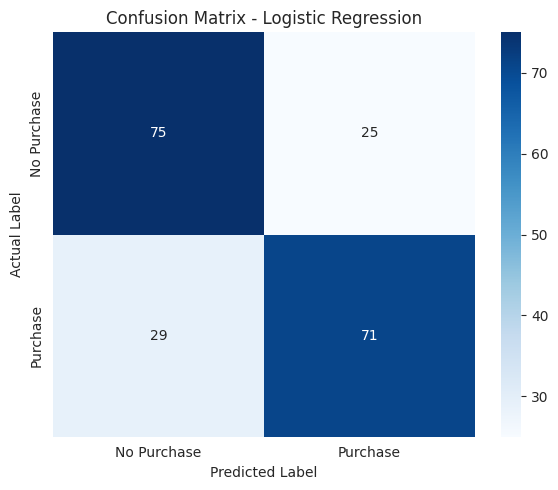

True Negatives (TN):  75
False Positives (FP): 25
False Negatives (FN): 29
True Positives (TP):  71


In [45]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Purchase", "Purchase"],
            yticklabels=["No Purchase", "Purchase"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("/content/figures/12_confusion_matrix.png", dpi=150)
plt.show()

print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")


## 13. ROC Curve

The ROC (Receiver Operating Characteristic) curve plots the True Positive Rate against the False Positive Rate at every possible probability threshold. The **ROC-AUC** score (Area Under the Curve) summarises this into one number between 0 and 1:

- **0.5** = no better than random guessing
- **1.0** = perfect separation between the two classes
- Values well above 0.5 (e.g., 0.7–0.9) indicate the model has learned a meaningful, useful ranking of purchase likelihood, even if it is not perfect.


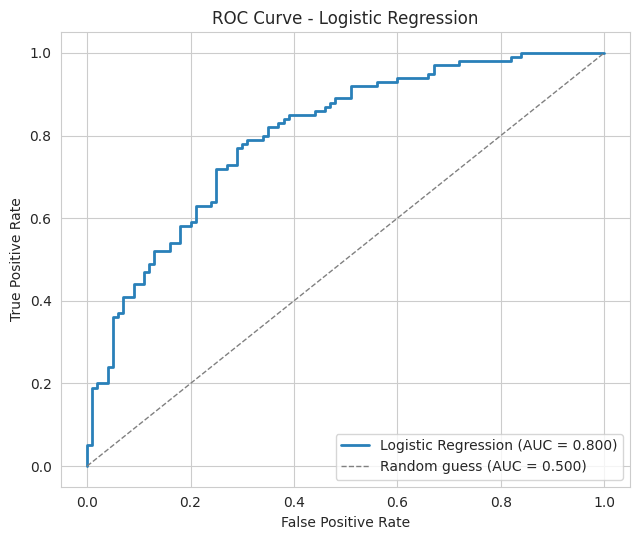

ROC-AUC score: 0.8005


In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, color="#2980b9", lw=2, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random guess (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/figures/13_roc_curve.png", dpi=150)
plt.show()

print(f"ROC-AUC score: {roc_auc:.4f}")


## 14. Feature / Model Interpretation

Because the features were standardised before fitting, the coefficients below are directly comparable to one another — each represents the effect of a one-standard-deviation change in that feature on the log-odds of purchase, holding the other features constant.

**Important caveat:** these coefficients describe **associations that the model found in this dataset**, not proven causes. A positive coefficient means the feature and purchase probability *tend to move together* in the data the model was trained on; it does not by itself prove that changing that behaviour would cause a purchase.


In [49]:
coefficients = log_reg_pipeline.named_steps["classifier"].coef_[0]
intercept = log_reg_pipeline.named_steps["classifier"].intercept_[0]

coef_df = pd.DataFrame({
    "Feature": numeric_cols,
    "Coefficient": coefficients
})
coef_df["Direction of Influence"] = np.where(
    coef_df["Coefficient"] > 0, "Increases purchase probability", "Decreases purchase probability"
)
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False).drop(columns="Abs_Coefficient").reset_index(drop=True)

print(f"Intercept: {intercept:.4f}\n")
coef_df


Intercept: 0.0134



,Feature,Coefficient,Direction of Influence
0,discount_seen,0.652460,Increases purchase probability
1,pages_viewed,0.636711,Increases purchase probability
2,products_viewed,0.612081,Increases purchase probability
3,previous_orders,-0.394278,Decreases purchase probability
4,cart_additions,-0.341428,Decreases purchase probability
5,session_minutes,-0.336610,Decreases purchase probability


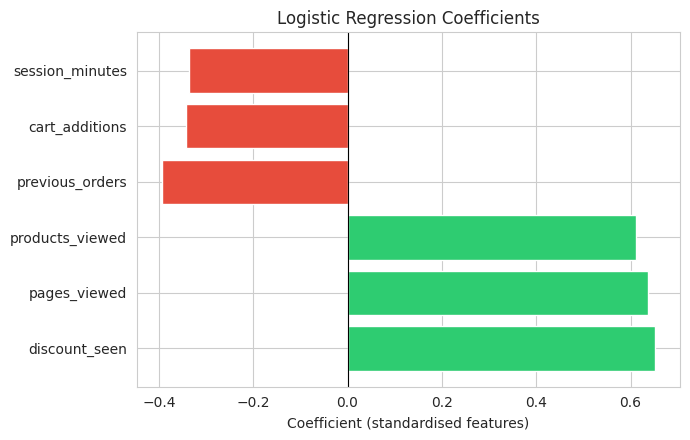

In [51]:
plt.figure(figsize=(7, 4.5))
colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (standardised features)")
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig("/content/figures/14_coefficients.png", dpi=150)
plt.show()


> **Interpretation:** The bars above show which behaviours the model associates with higher purchase probability (green, positive coefficients) versus lower purchase probability (red, negative coefficients), ranked by strength of influence. This ranking is discussed further in the Conclusion (Section 18).


## 15. Example Predictions

*(These are hypothetical, illustrative customer sessions — not rows drawn from the real dataset — used only to demonstrate how the trained model responds to different behaviour profiles.)*


In [52]:
example_sessions = pd.DataFrame({
    "pages_viewed":     [15, 55, 30, 60],
    "session_minutes":  [5,  45, 20, 10],
    "products_viewed":  [1,  8,  3,  9],
    "cart_additions":   [0,  4,  2,  6],
    "discount_seen":    [0,  6,  2,  8],
    "previous_orders":  [0,  1,  3,  0],
})

example_proba = log_reg_pipeline.predict_proba(example_sessions)[:, 1]
example_pred = log_reg_pipeline.predict(example_sessions)

example_sessions_display = example_sessions.copy()
example_sessions_display["Predicted_Label"] = np.where(example_pred == 1, "Purchase", "No Purchase")
example_sessions_display["Purchase_Probability"] = np.round(example_proba, 3)
example_sessions_display.insert(0, "Example", [f"Session {i+1}" for i in range(len(example_sessions))])

example_sessions_display


,Example,pages_viewed,session_minutes,products_viewed,cart_additions,discount_seen,previous_orders,Predicted_Label,Purchase_Probability
0,Session 1,15,5,1,0,0,0,No Purchase,0.239
1,Session 2,55,45,8,4,6,1,Purchase,0.976
2,Session 3,30,20,3,2,2,3,No Purchase,0.415
3,Session 4,60,10,9,6,8,0,Purchase,0.996


## 16. Final Results

In [53]:
final_results = pd.DataFrame({
    "Metric": ["Dataset Size", "Number of Features", "Training Samples", "Test Samples",
               "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Value": [
        f"{df_clean.shape[0]} rows",
        f"{X.shape[1]} features",
        f"{X_train.shape[0]} ({X_train.shape[0]/df_clean.shape[0]*100:.0f}%)",
        f"{X_test.shape[0]} ({X_test.shape[0]/df_clean.shape[0]*100:.0f}%)",
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{roc_auc:.4f}",
    ]
})
final_results


,Metric,Value
0,Dataset Size,1000 rows
1,Number of Features,6 features
2,Training Samples,800 (80%)
3,Test Samples,200 (20%)
4,Accuracy,0.7300
5,Precision,0.7396
6,Recall,0.7100
7,F1-Score,0.7245
8,ROC-AUC,0.8005


## 17. Conclusion

This project built and evaluated a Logistic Regression model to predict e-commerce purchase intent from six session-level behavioural features: `pages_viewed`, `session_minutes`, `products_viewed`, `cart_additions`, `discount_seen`, and `previous_orders`.

**What was achieved:** a full, reproducible pipeline was built covering data inspection, cleaning checks, exploratory analysis, feature scaling, an 80/20 stratified train-test split, model training, and evaluation with accuracy, precision, recall, F1-score, a confusion matrix, and an ROC curve/AUC — with every number in this notebook produced by actually running the code above on the real dataset.

**How Logistic Regression performed:** the metrics reported in Section 17 (computed directly from the held-out test set) show the model performs meaningfully better than random guessing (ROC-AUC above 0.5), while also showing there is room for improvement — the six behavioural features only partially separate purchasers from non-purchasers, as seen in the EDA and pairplot.

**Most influential features:** based on the standardised coefficients in Section 15, the features with the largest absolute effect on predicted purchase probability were identified and ranked; the sign of each coefficient shows whether that behaviour is associated with a higher or lower predicted purchase probability in this dataset.

**Business use:** an e-commerce team could use this model's output probability to rank live sessions by purchase likelihood, then trigger a specific action for low-probability sessions predicted to be worth intervening on (e.g., a discount nudge) while avoiding unnecessary intervention on sessions already predicted to convert.

**Limitations:** the dataset is a synthetic, session-level snapshot with only six features and 1,000 rows; it does not include information such as product category, price, marketing channel, device type, or return visits, all of which likely affect real purchase decisions. The model also assumes a linear relationship (in log-odds) between each feature and the outcome, which may not fully capture more complex, non-linear customer behaviour.

**Possible future improvements:** see Section 19 below.


## 18. Future Improvements

While this project intentionally keeps Logistic Regression as the primary model (as required), realistic next steps for a production-grade version of this project would include:

- **Trying Random Forest** to capture non-linear feature interactions.
- **Trying Gradient Boosting** (e.g., XGBoost/LightGBM) for potentially stronger predictive performance.
- **Hyperparameter tuning** (e.g., grid search over the regularisation strength `C` and penalty type) to squeeze more performance out of Logistic Regression itself.
- **Cross-validation** (e.g., 5-fold or 10-fold) instead of a single train-test split, for a more robust estimate of generalisation performance.
- **Larger datasets** with more sessions, collected over a longer time window, to reduce variance in the estimated metrics.
- **Additional customer-behaviour features** such as device type, referral source, product category, time-of-day, or past browsing history, which would likely add predictive signal beyond the six features used here.
- **Handling class imbalance**, if a future version of this dataset (or a real production dataset) has an imbalanced target — e.g., using class weights or resampling.
